# Case Study On Wedding Halls

# Wedding Hall Price Prediction using Machine Learning
This notebook focuses on applying various machine learning models to predict wedding hall prices based on features such as hall type, ratings, reviews, menu price, capacity, etc.

In [1]:
# using warning library to the ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the data
df=pd.read_csv("Venues_data.csv")
df.head()

,Name,Type,Ratings,Reviews,Menu_Price,Rooms,Pax_Min,Pax_Max,Destination,Amenities_+more
0,cherish ballrooms at imperial club of india,"banquet halls, marriage garden / lawns",5.0,4,3000.0,20,80,650,ncr,4
1,lado rani banquet,"banquet halls, 3 star hotels with banquets",5.0,2,1000.0,35,125,600,ncr,4
2,"fortune park orange, sidhrawali, gurugram - it...","4 star & above wedding hotels, banquet halls",5.0,4,2500.0,96,200,1000,ncr,4
3,spara boutique resort,"banquet halls, marriage garden / lawns",4.8,2,4000.0,39,200,1200,ncr,4
4,21 century event space,marriage garden / lawns,5.0,5,850.0,2,300,600,chennai,3


In [4]:
# check for all the columns
df.columns

Index(['Name', 'Type', 'Ratings', 'Reviews', 'Menu_Price', 'Rooms', 'Pax_Min',
       'Pax_Max', 'Destination', 'Amenities_+more'],
      dtype='object')

`Name` defines name for each venue

`Type` defines which type of hall it is

`Ratings` ratings out of 5

`Reviews` shows reviews out of 5

`Menu Price` price in Indian Rupees

`Rooms` total number of rooms for each venue

`Pax Min` shows minimum capacity of passengers

`Pax Max` shows maximum capacity of passengers

`Destination` showcases location for thr venue

`Amenities +more` shows how many services each venue provides

In [5]:
# look for the shape
df.shape

(1927, 10)

In [6]:
# look for all the information about dataset/ attributes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1927 entries, 0 to 1926
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             1927 non-null   object 
 1   Type             1927 non-null   object 
 2   Ratings          1927 non-null   float64
 3   Reviews          1927 non-null   int64  
 4   Menu_Price       1927 non-null   float64
 5   Rooms            1927 non-null   int64  
 6   Pax_Min          1927 non-null   int64  
 7   Pax_Max          1927 non-null   int64  
 8   Destination      1927 non-null   object 
 9   Amenities_+more  1927 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 150.7+ KB


In [7]:
# check for null values
df.isnull().sum()

Name               0
Type               0
Ratings            0
Reviews            0
Menu_Price         0
Rooms              0
Pax_Min            0
Pax_Max            0
Destination        0
Amenities_+more    0
dtype: int64

In [8]:
# checl for duplicates
df.duplicated().sum()

0

In [9]:
# check mathematical description for all the data
df.describe(include="all")

,Name,Type,Ratings,Reviews,Menu_Price,Rooms,Pax_Min,Pax_Max,Destination,Amenities_+more
count,1927,1927,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927,1927.000000
unique,1918,45,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN
top,hotel mohan,"banquet halls, marriage garden / lawns",NaN,NaN,NaN,NaN,NaN,NaN,jaipur,NaN
freq,2,455,NaN,NaN,NaN,NaN,NaN,NaN,412,NaN
mean,NaN,NaN,4.978049,0.773223,9885.560457,25.864037,252.212247,546.920083,NaN,2.602491
std,NaN,NaN,0.094724,1.141563,48302.554711,28.949255,198.593005,400.983245,NaN,0.711684
min,NaN,NaN,4.500000,0.000000,80.000000,1.000000,0.000000,0.000000,NaN,1.000000
25%,NaN,NaN,5.000000,0.000000,432.500000,21.000000,100.000000,250.000000,NaN,2.000000
50%,NaN,NaN,5.000000,0.000000,650.000000,21.000000,200.000000,500.000000,NaN,3.000000
75%,NaN,NaN,5.000000,1.000000,1000.000000,21.000000,350.000000,750.000000,NaN,3.000000


In [10]:
# check value counts for each categorical column
df["Name"].value_counts()

Name
hotel mohan            2
bikanervala            2
atlantis               2
emerald greens         2
utsav marriage hall    2
                      ..
the yellow chilli      1
patan mahal            1
heera valley resort    1
cygnett style ganga    1
gokul vatika           1
Name: count, Length: 1918, dtype: int64

In [11]:
df["Type"].value_counts()

Type
banquet halls, marriage garden / lawns                           455
banquet halls                                                    368
banquet halls, 3 star hotels with banquets                       326
marriage garden / lawns                                          196
banquet halls, convention / function halls                        95
banquet halls, small function / party halls                       79
4 star & above wedding hotels, banquet halls                      69
banquet halls, venues with rooms                                  58
small function / party halls                                      45
marriage garden / lawns, 3 star hotels with banquets              35
banquet halls, kalyana mandapams                                  32
marriage garden / lawns, wedding farmhouses                       28
3 star hotels with banquets, small function / party halls         18
marriage garden / lawns, venues with rooms                        17
3 star hotels with banquets, 

In [12]:
df["Destination"].value_counts()

Destination
jaipur     412
chennai    408
lucknow    403
pune       374
ncr        330
Name: count, dtype: int64

## Data Cleaning and Preprocessing


In [13]:
# checking whether any of the numerical columns containing zero value
print(df.loc[(df["Ratings"]==0) | (df["Reviews"]==0) | (df["Menu_Price"]==0) | (df["Rooms"]==0) | (df["Pax_Min"]==0) | (df["Pax_Max"]==0) | (df["Amenities_+more"]==0)])

                                          Name  \
112                   surestay by best western   
118                   shyam shanti guest house   
124                  hotel venus palace & lawn   
159   bougainvilla resort park by dream villas   
168            k rocks resort lakeside camping   
...                                        ...   
1919                            hotel om tower   
1921                      hotel shyam paradise   
1922                       hotel grand capitol   
1924                                    skylit   
1926                              gokul vatika   

                                              Type  Ratings  Reviews  \
112   4 star & above wedding hotels, banquet halls      5.0        0   
118                                  banquet halls      5.0        0   
124         banquet halls, marriage garden / lawns      5.0        0   
159       marriage garden / lawns, wedding resorts      5.0        0   
168    marriage garden / lawns, wedding

In [14]:
print(len(df.loc[(df["Ratings"]==0) | (df["Reviews"]==0) | (df["Menu_Price"]==0) | (df["Rooms"]==0) | (df["Pax_Min"]==0) | (df["Pax_Max"]==0) | (df["Amenities_+more"]==0)]))

1069


In [15]:
print(len(df.loc[(df["Ratings"]==0)]))

0


In [16]:
# review column contains most of the zero value 
print(len(df.loc[(df["Reviews"]==0)]))

1069


In [17]:
print(len(df.loc[(df["Menu_Price"]==0)]))

0


In [18]:
print(len(df.loc[(df["Rooms"]==0)]))

0


In [19]:
print(len(df.loc[(df["Pax_Max"]==0)]))

2


In [20]:
print(len(df.loc[(df["Pax_Min"]==0)]))

2


In [21]:
# droppping reviews column because it contains most percent of zero values
df.drop("Reviews",axis=1,inplace=True)

In [22]:
# receck the data
df.head()

,Name,Type,Ratings,Menu_Price,Rooms,Pax_Min,Pax_Max,Destination,Amenities_+more
0,cherish ballrooms at imperial club of india,"banquet halls, marriage garden / lawns",5.0,3000.0,20,80,650,ncr,4
1,lado rani banquet,"banquet halls, 3 star hotels with banquets",5.0,1000.0,35,125,600,ncr,4
2,"fortune park orange, sidhrawali, gurugram - it...","4 star & above wedding hotels, banquet halls",5.0,2500.0,96,200,1000,ncr,4
3,spara boutique resort,"banquet halls, marriage garden / lawns",4.8,4000.0,39,200,1200,ncr,4
4,21 century event space,marriage garden / lawns,5.0,850.0,2,300,600,chennai,3


In [23]:
# divide data into two parts that is categorical and numerical 

In [24]:
numeric_df= df.select_dtypes(include=["number"])

In [25]:
category_df= df.select_dtypes(include=["object"])

In [26]:
# label encoding on training categorical data
x_train_cat_le= pd.DataFrame(index=category_df.index)
x_train_cat_le.head()

""
0
1
2
3
4


<Axes: >

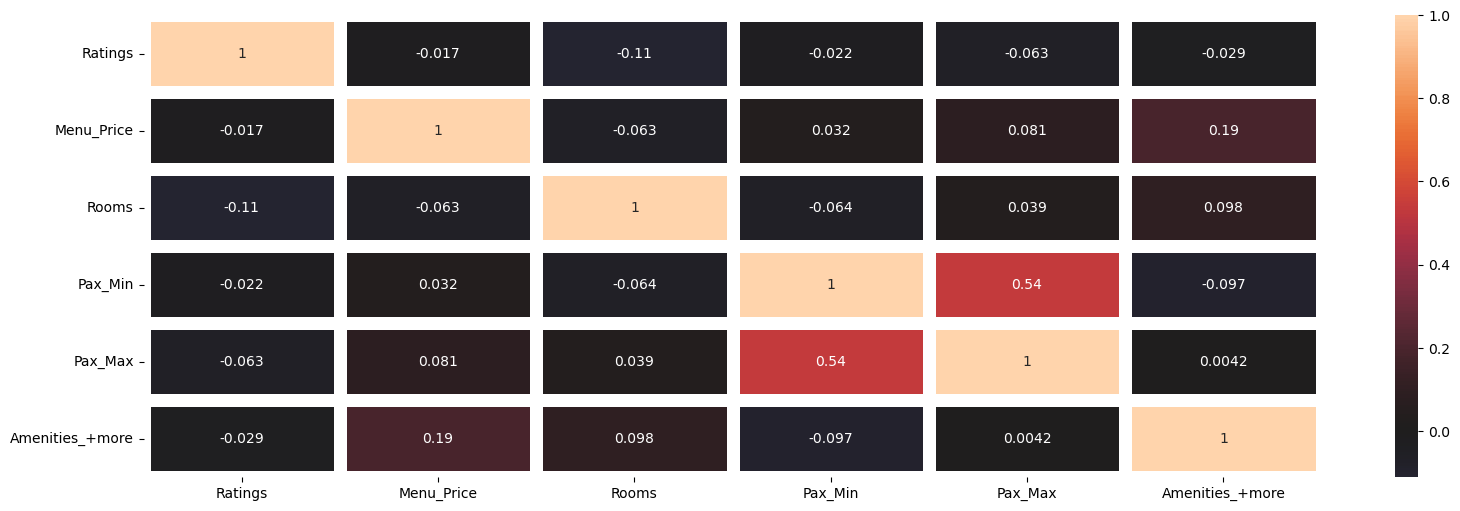

In [27]:
f,ax= plt.subplots(figsize=(19,6))
sns.heatmap(numeric_df.corr(),annot=True,linewidths=8,center=0,ax=ax)

In [28]:
Type_U_L= ['banquet halls, marriage garden / lawns',
       'banquet halls, 3 star hotels with banquets',
       '4 star & above wedding hotels, banquet halls',
       'marriage garden / lawns', 'banquet halls',
       'marriage garden / lawns, 3 star hotels with banquets',
       'marriage garden / lawns, party restaurants / lounge bars',
       'marriage garden / lawns, wedding farmhouses',
       'banquet halls, venues with rooms',
       'banquet halls, convention / function halls',
       'banquet halls, kalyana mandapams',
       '3 star hotels with banquets, destination wedding venues',
       'marriage garden / lawns, convention / function halls',
       'banquet halls, small function / party halls',
       '4 star & above wedding hotels, 3 star hotels with banquets',
       'marriage garden / lawns, destination wedding venues',
       'banquet halls, wedding resorts', 'wedding resorts',
       'marriage garden / lawns, venues with rooms',
       'small function / party halls',
       'marriage garden / lawns, wedding resorts',
       '3 star hotels with banquets',
       '4 star & above wedding hotels, marriage garden / lawns',
       'party restaurants / lounge bars, small function / party halls',
       'wedding farmhouses',
       'marriage garden / lawns, small function / party halls',
       '3 star hotels with banquets, venues with rooms',
       'small function / party halls, small function / party halls',
       '4 star & above wedding hotels, destination wedding venues',
       '3 star hotels with banquets, small function / party halls',
       'marriage garden / lawns, kalyana mandapams',
       'party restaurants / lounge bars',
       'banquet halls, party restaurants / lounge bars',
       '4 star & above wedding hotels, venues with rooms',
       'party restaurants / lounge bars, banquet halls',
       '4 star & above wedding hotels, wedding resorts',
       'banquet halls, destination wedding venues',
       'small function / party halls, venues with rooms',
       'wedding resorts, venues with rooms',
       'small function / party halls, 3 star hotels with banquets',
       '3 star hotels with banquets, party restaurants / lounge bars',
       'banquet halls, 4 star & above wedding hotels',
       'party restaurants / lounge bars, marriage garden / lawns',
       'marriage garden / lawns, banquet halls',
       '3 star hotels with banquets, convention / function halls']

In [29]:
# manually giving labels for Type column
unique_type = {}
counter = 1

for i in Type_U_L:
    unique_type[i] = counter
    counter += 1

print(unique_type)


{'banquet halls, marriage garden / lawns': 1, 'banquet halls, 3 star hotels with banquets': 2, '4 star & above wedding hotels, banquet halls': 3, 'marriage garden / lawns': 4, 'banquet halls': 5, 'marriage garden / lawns, 3 star hotels with banquets': 6, 'marriage garden / lawns, party restaurants / lounge bars': 7, 'marriage garden / lawns, wedding farmhouses': 8, 'banquet halls, venues with rooms': 9, 'banquet halls, convention / function halls': 10, 'banquet halls, kalyana mandapams': 11, '3 star hotels with banquets, destination wedding venues': 12, 'marriage garden / lawns, convention / function halls': 13, 'banquet halls, small function / party halls': 14, '4 star & above wedding hotels, 3 star hotels with banquets': 15, 'marriage garden / lawns, destination wedding venues': 16, 'banquet halls, wedding resorts': 17, 'wedding resorts': 18, 'marriage garden / lawns, venues with rooms': 19, 'small function / party halls': 20, 'marriage garden / lawns, wedding resorts': 21, '3 star h

In [30]:
# manually giving labels to destination
destination_encoder= {"pune":1, "chennai":2, "lucknow":3, "ncr":4, "jaipur":5}

In [31]:
df["Type_Label"]= df["Type"].map(unique_type)

In [32]:
df["Destination_Label"]= df["Destination"].map(destination_encoder)

In [33]:
df.head()

,Name,Type,Ratings,Menu_Price,Rooms,Pax_Min,Pax_Max,Destination,Amenities_+more,Type_Label,Destination_Label
0,cherish ballrooms at imperial club of india,"banquet halls, marriage garden / lawns",5.0,3000.0,20,80,650,ncr,4,1,4
1,lado rani banquet,"banquet halls, 3 star hotels with banquets",5.0,1000.0,35,125,600,ncr,4,2,4
2,"fortune park orange, sidhrawali, gurugram - it...","4 star & above wedding hotels, banquet halls",5.0,2500.0,96,200,1000,ncr,4,3,4
3,spara boutique resort,"banquet halls, marriage garden / lawns",4.8,4000.0,39,200,1200,ncr,4,1,4
4,21 century event space,marriage garden / lawns,5.0,850.0,2,300,600,chennai,3,4,2


In [34]:
# check for the skewness of the data 
df["Menu_Price"].skew()

9.476818138205982

In [35]:
# normalizing the menu price of our data or taking the log value of the menu price column
# (because menu price column contains high range of menu prices i.e outliers, 
# but those outliers were needed because menu price is our target variable, so didn't handle those or removed those)
# there's need to convert all the values to log form, so that our data can be normalized on the same scale and model is able to predict without any biasness
df["Price_Log"]= pd.DataFrame({"Menu_Price": np.log(df["Menu_Price"])})
df.head()

,Name,Type,Ratings,Menu_Price,Rooms,Pax_Min,Pax_Max,Destination,Amenities_+more,Type_Label,Destination_Label,Price_Log
0,cherish ballrooms at imperial club of india,"banquet halls, marriage garden / lawns",5.0,3000.0,20,80,650,ncr,4,1,4,8.006368
1,lado rani banquet,"banquet halls, 3 star hotels with banquets",5.0,1000.0,35,125,600,ncr,4,2,4,6.907755
2,"fortune park orange, sidhrawali, gurugram - it...","4 star & above wedding hotels, banquet halls",5.0,2500.0,96,200,1000,ncr,4,3,4,7.824046
3,spara boutique resort,"banquet halls, marriage garden / lawns",4.8,4000.0,39,200,1200,ncr,4,1,4,8.294050
4,21 century event space,marriage garden / lawns,5.0,850.0,2,300,600,chennai,3,4,2,6.745236


In [36]:
# skewness after taking log values
df["Price_Log"].skew()

2.5082256285808273

## Model Training and Evaluation
experimented with different regression algorithms such as Linear Regression, Random Forest, and Decision Tree to predict venue pricing.


In [37]:
# our target variable is "Price", it is numerical feature, so our task is going to be "Regression Task"

In [38]:
# now divide target variable and training data 
y= df["Price_Log"]
x= df[["Ratings","Rooms","Pax_Max","Pax_Min","Amenities_+more","Type_Label","Destination_Label"]]

In [39]:
# Train Test Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state= 10)

In [40]:
cols= ["Ratings","Rooms","Pax_Max","Pax_Min","Amenities_+more","Type_Label","Destination_Label"]

In [41]:
# Standardizing the x train and test
from sklearn.preprocessing import StandardScaler
scale= StandardScaler()
x_train_transformed= pd.DataFrame(scale.fit_transform(x_train), columns=cols, index=x_train.index)
x_test_transformed= pd.DataFrame(scale.transform(x_test), columns=cols, index=x_test.index)
print(x_train_transformed.head())

       Ratings     Rooms   Pax_Max   Pax_Min  Amenities_+more  Type_Label  \
1889  0.232639 -0.182074 -0.107605 -0.243290        -2.265899    0.588689   
126   0.232639 -0.182074 -0.107605 -0.243290        -0.856230   -0.418478   
1219  0.232639  1.107838  0.389120 -1.054948         0.553439   -0.418478   
1320  0.232639 -0.221162 -0.604330 -0.243290         1.963109   -0.562359   
565   0.232639 -0.572956 -0.604330 -0.344747         0.553439   -0.562359   

      Destination_Label  
1889          -1.418312  
126            1.386460  
1219          -0.717119  
1320           1.386460  
565            1.386460  


In [42]:
x_train_transformed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1541 entries, 1889 to 1289
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Ratings            1541 non-null   float64
 1   Rooms              1541 non-null   float64
 2   Pax_Max            1541 non-null   float64
 3   Pax_Min            1541 non-null   float64
 4   Amenities_+more    1541 non-null   float64
 5   Type_Label         1541 non-null   float64
 6   Destination_Label  1541 non-null   float64
dtypes: float64(7)
memory usage: 96.3 KB


## Model Performance
Among all tested models, the Decision Tree Regressor performed best with the highest R² score and lowest error metrics.


In [43]:
#Linear Regression
from sklearn.linear_model import LinearRegression
regressor= LinearRegression()
regressor.fit(x_train_transformed, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
y_test_pred= regressor.predict(x_test_transformed)

In [45]:
temp_df= pd.DataFrame({"Actual": y_test, "Predicted": y_test_pred})
temp_df.head()

,Actual,Predicted
1143,5.703782,6.290626
874,5.857933,6.246228
1736,6.684612,7.198746
1436,5.857933,7.036395
1640,6.620073,7.214630


<Axes: xlabel='Price_Log', ylabel='Count'>

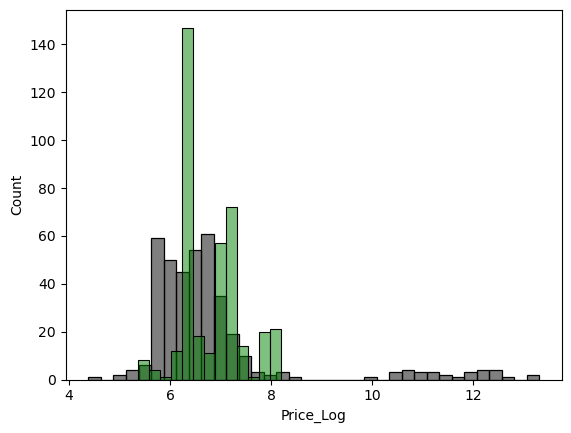

In [46]:
sns.histplot(y_test, color="black", alpha=0.5)
sns.histplot(y_test_pred, color="green", alpha=0.5)

In [47]:
from sklearn import metrics
print("Mean Absolute Error: ", metrics.mean_absolute_error(y_test, y_test_pred))
print("Mean Squared Error: ", metrics.mean_squared_error(y_test, y_test_pred))
print("Root Mean Squared Error: ", np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

Mean Absolute Error:  0.8869921395616949
Mean Squared Error:  2.0212873913183382
Root Mean Squared Error:  1.4217198709022598


In [48]:
# KNN Regression
from sklearn.neighbors import KNeighborsRegressor
regressor= KNeighborsRegressor()
regressor.fit(x_train_transformed, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [49]:
y_test_pred= regressor.predict(x_test_transformed)

In [50]:
temp_df2= pd.DataFrame({"Actual":y_test, "Predicted": y_test_pred})
temp_df2.head()

,Actual,Predicted
1143,5.703782,5.656050
874,5.857933,5.991416
1736,6.684612,6.032944
1436,5.857933,6.514890
1640,6.620073,6.559081


<Axes: xlabel='Price_Log', ylabel='Count'>

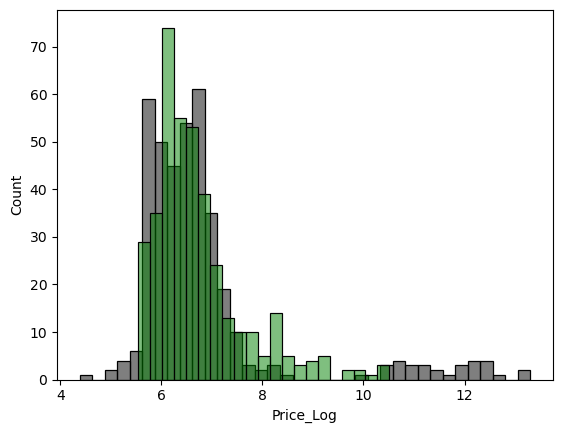

In [51]:
sns.histplot(y_test, color="black", alpha=0.5)
sns.histplot(y_test_pred, color="green", alpha=0.5)

In [52]:
from sklearn import metrics
print("Mean Absolute Error: ", metrics.mean_absolute_error(y_test, y_test_pred))
print("Mean Squared Error: ", metrics.mean_squared_error(y_test, y_test_pred))
print("Root Mean Squared Error: ", np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

Mean Absolute Error:  0.800929820722046
Mean Squared Error:  2.012875467106241
Root Mean Squared Error:  1.4187584245058216


In [53]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
regressor= DecisionTreeRegressor()
regressor.fit(x_train_transformed, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [54]:
y_test_pred= regressor.predict(x_test_transformed)

In [55]:
temp_df= pd.DataFrame({"Actual": y_test, "Pedicted": y_test_pred})
temp_df.head()

,Actual,Pedicted
1143,5.703782,5.857933
874,5.857933,5.943477
1736,6.684612,6.109248
1436,5.857933,6.309918
1640,6.620073,6.684612


<Axes: xlabel='Price_Log', ylabel='Count'>

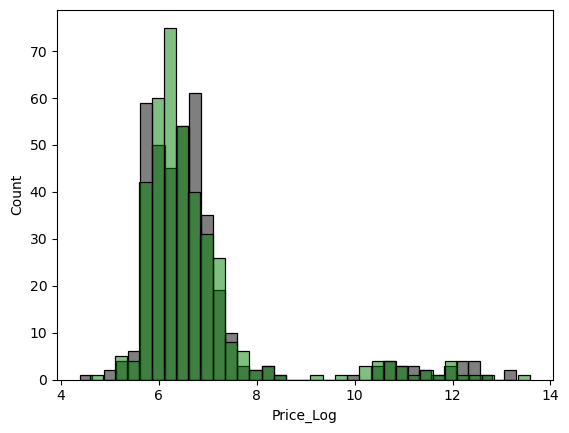

In [56]:
sns.histplot(y_test, color="black", alpha=0.5)
sns.histplot(y_test_pred, color="green", alpha=0.5)

In [57]:
from sklearn import metrics
print("Mean Absolute Error: ", metrics.mean_absolute_error(y_test, y_test_pred))
print("Mean Squared Error: ", metrics.mean_squared_error(y_test, y_test_pred))
print("Root Mean Squared Error: ", np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

Mean Absolute Error:  0.831811160932131
Mean Squared Error:  2.5709907750626884
Root Mean Squared Error:  1.6034309386633052


In [58]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
regressor= RandomForestRegressor()
regressor.fit(x_train_transformed,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
y_test_pred= regressor.predict(x_test_transformed)

In [60]:
temp_df= pd.DataFrame({"Actual":y_test, "Predicted": y_test_pred})
temp_df.head()

,Actual,Predicted
1143,5.703782,5.796939
874,5.857933,5.932646
1736,6.684612,5.860213
1436,5.857933,6.473724
1640,6.620073,6.624986


<Axes: xlabel='Price_Log', ylabel='Count'>

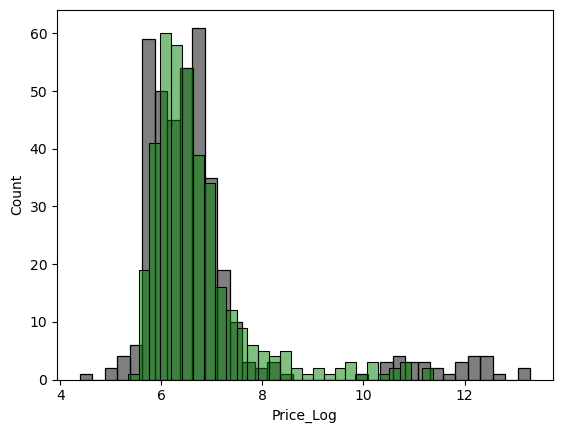

In [61]:
sns.histplot(y_test, color="black", alpha=0.5)
sns.histplot(y_test_pred, color="green", alpha=0.5)

In [62]:
from sklearn import metrics
print("Mean Absolute Error: ", metrics.mean_absolute_error(y_test, y_test_pred))
print("Mean Squared Error: ", metrics.mean_squared_error(y_test, y_test_pred))
print("Root Mean Squared Error: ", np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

Mean Absolute Error:  0.7065939694961604
Mean Squared Error:  1.756888625278292
Root Mean Squared Error:  1.3254767539562102


In [63]:
# Support Vector Regressor
from sklearn.svm import SVR
regressor= SVR()
regressor.fit(x_train_transformed, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [64]:
y_test_pred= regressor.predict(x_test_transformed)

In [65]:
temp_df= pd.DataFrame({"Actual":y_test, "Predicted": y_test_pred})
temp_df.head()

,Actual,Predicted
1143,5.703782,5.900152
874,5.857933,5.840036
1736,6.684612,6.225152
1436,5.857933,6.612004
1640,6.620073,6.634341


<Axes: xlabel='Price_Log', ylabel='Count'>

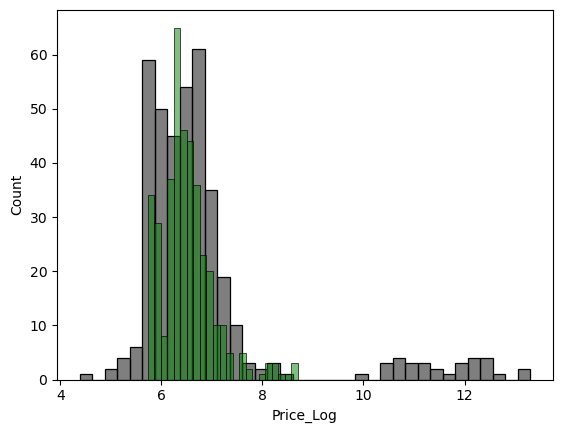

In [66]:
sns.histplot(y_test, color="black", alpha=0.5)
sns.histplot(y_test_pred, color="green", alpha=0.5)

In [67]:
from sklearn import metrics
print("Mean Absolute Error: ", metrics.mean_absolute_error(y_test, y_test_pred))
print("Mean Squared Error: ", metrics.mean_squared_error(y_test, y_test_pred))
print("Root Mean Squared Error: ", np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

Mean Absolute Error:  0.7383368612386834
Mean Squared Error:  2.122172081777761
Root Mean Squared Error:  1.4567676828436855


## As we can see Linear Regression Algorithm has worked better among all

## Conclusion
The Linear Regression model provides reliable predictions for wedding hall prices and can be used as a base model for future improvements.
